<a href="https://colab.research.google.com/github/Tanja000/Trading/blob/main/Kupfer_Chip_Correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1360/3855925589.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(list(tickers.values()), period="1y")["Close"]
[*********************100%***********************]  2 of 2 completed


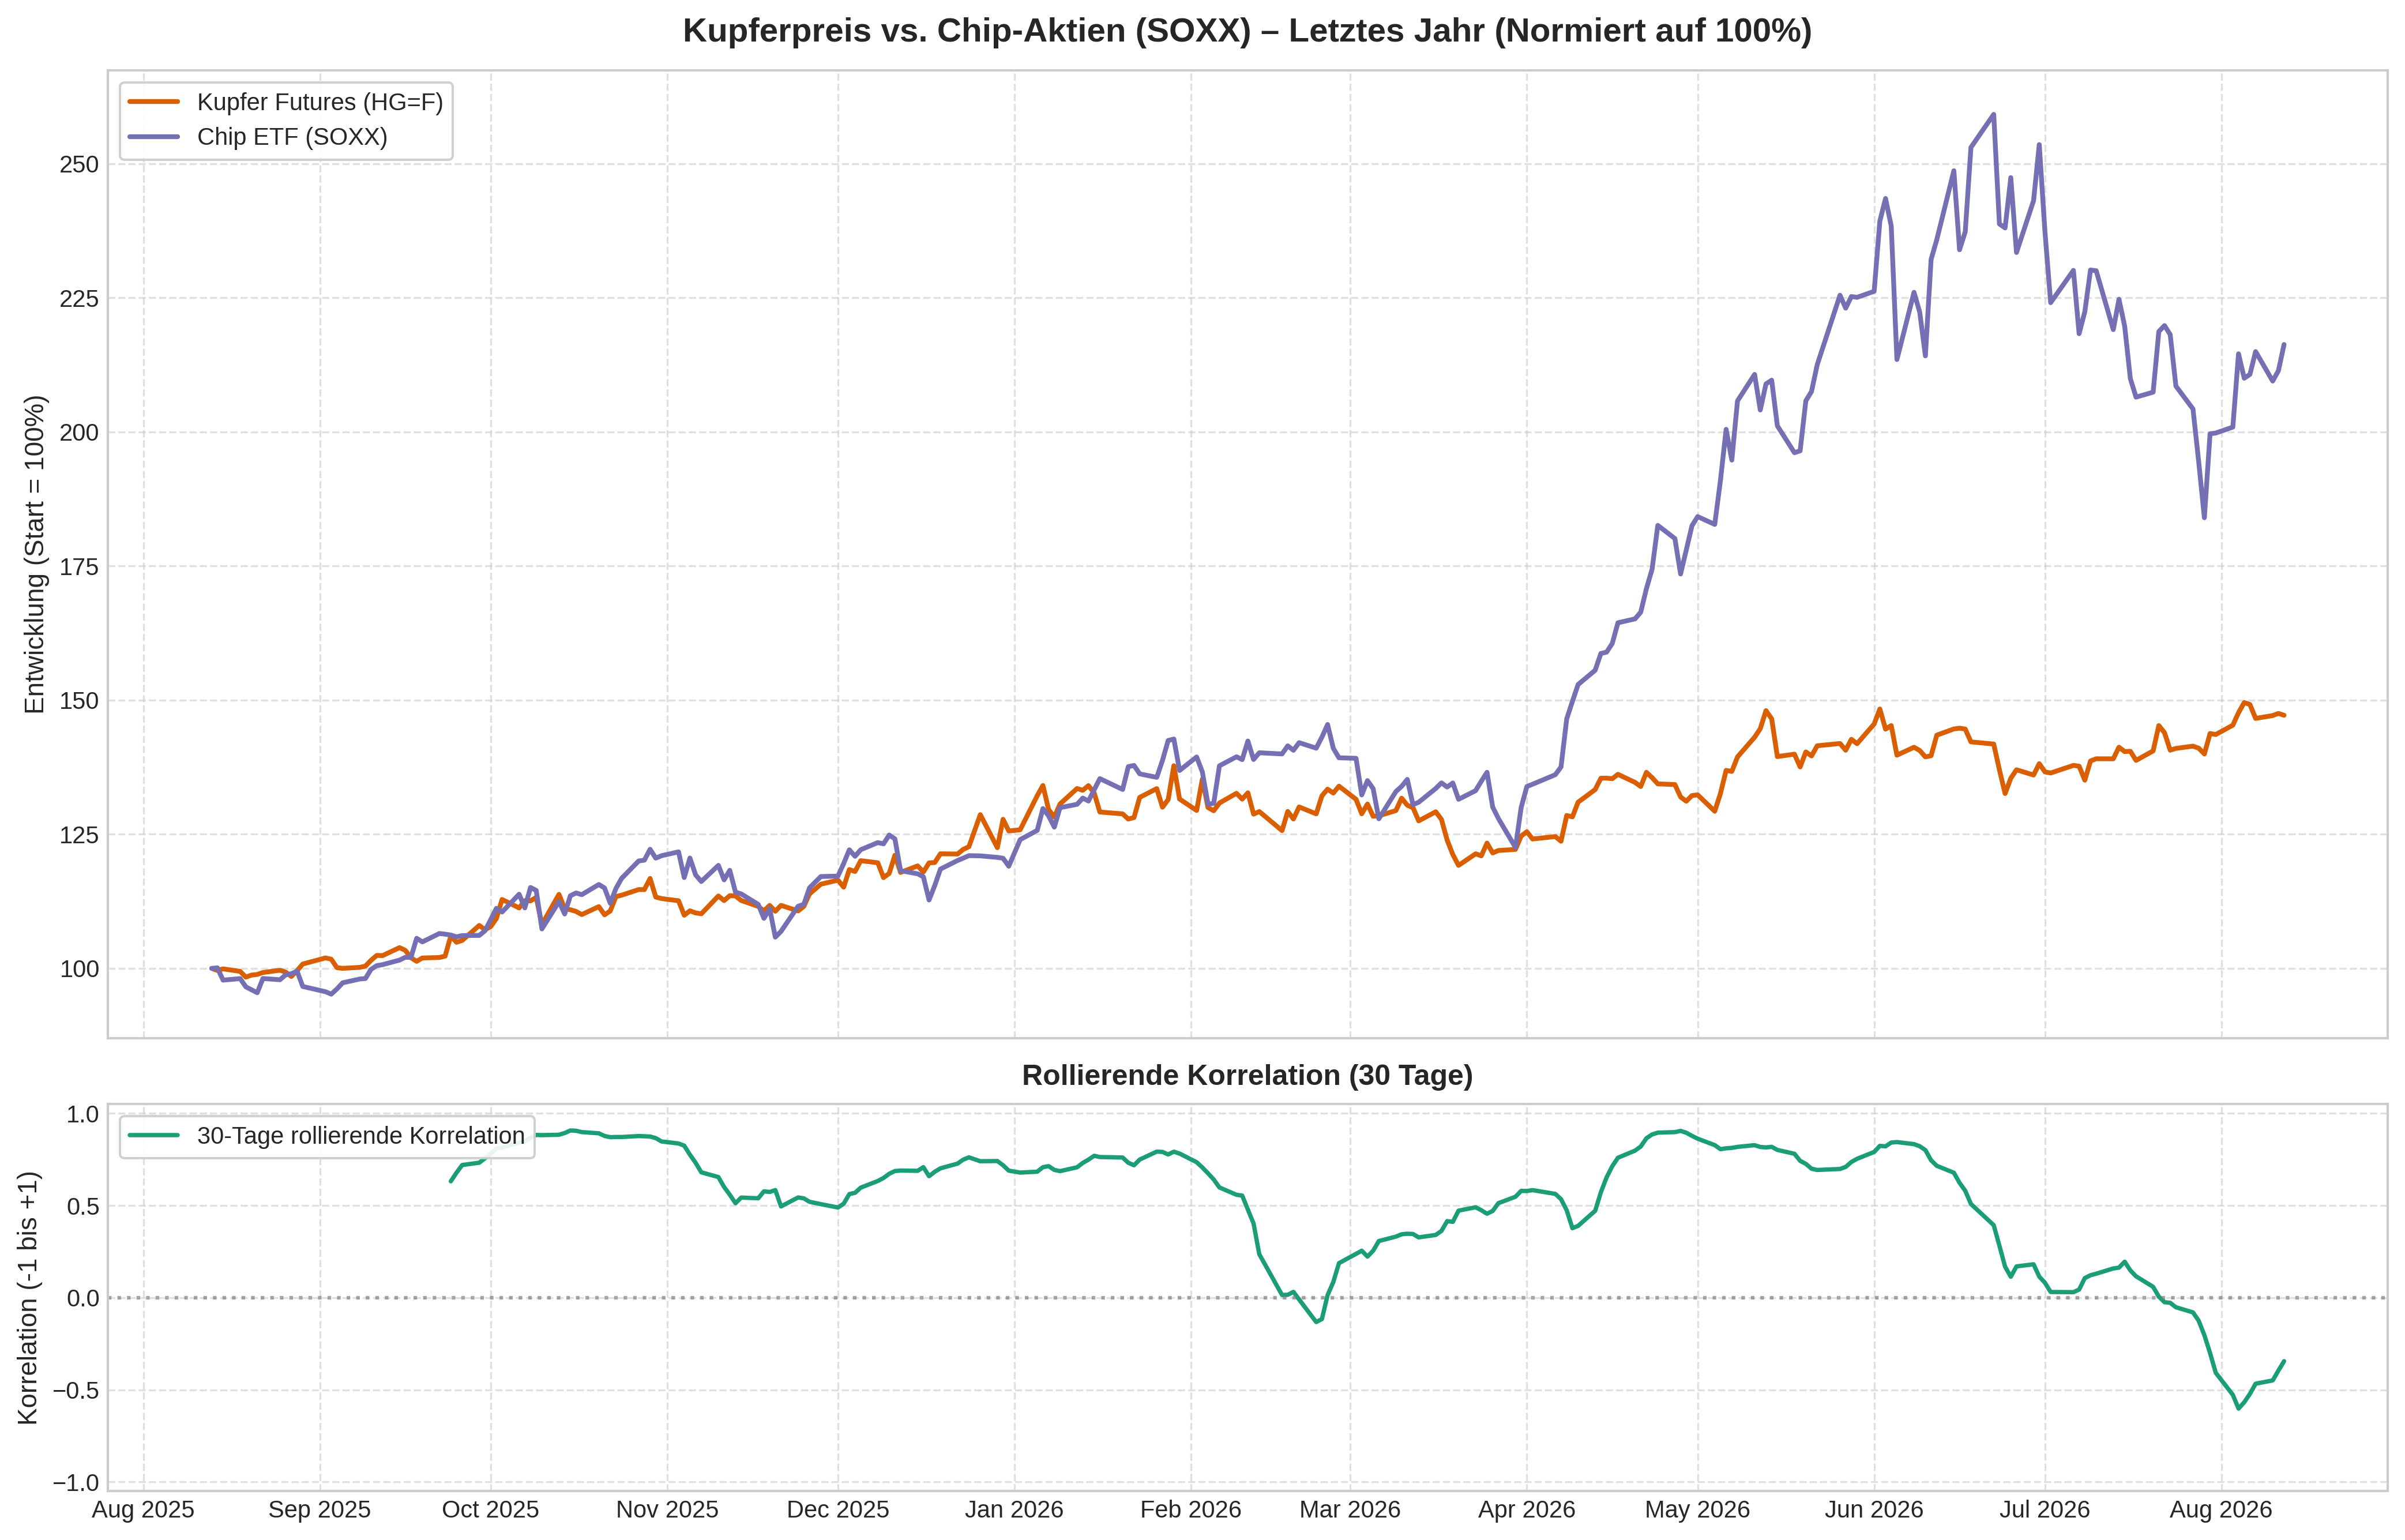

Chart generated successfully.


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set style for a clean professional look
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Download 1 year of data
tickers = {"Kupfer (HG=F)": "HG=F", "Chip ETF (SOXX)": "SOXX"}
df = yf.download(list(tickers.values()), period="1y")["Close"]

# Rename columns cleanly
df = df.rename(columns={v: k for k, v in tickers.items()})
df = df.dropna()

# Normalize prices to percentage change (base 100 at start of period)
norm_df = (df / df.iloc[0]) * 100

# Calculate 30-day rolling correlation between Copper and Chip ETF
df['Correlation'] = df['Kupfer (HG=F)'].rolling(window=30).corr(df['Chip ETF (SOXX)'])

# Create figure with high DPI and 2 subplots (top: prices, bottom: correlation)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]}, dpi=300)

# Plot 1: Normalized Prices
ax1.plot(norm_df.index, norm_df['Kupfer (HG=F)'], label='Kupfer Futures (HG=F)', color='#d95f02', linewidth=2)
ax1.plot(norm_df.index, norm_df['Chip ETF (SOXX)'], label='Chip ETF (SOXX)', color='#7570b3', linewidth=2)
ax1.set_title('Kupferpreis vs. Chip-Aktien (SOXX) – Letztes Jahr (Normiert auf 100%)', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Entwicklung (Start = 100%)', fontsize=11)
ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Rolling Correlation Line
ax2.plot(df.index, df['Correlation'], label='30-Tage rollierende Korrelation', color='#1b9e77', linewidth=1.8)
ax2.axhline(0, color='gray', linestyle=':', alpha=0.7)
ax2.set_title('Rollierende Korrelation (30 Tage)', fontsize=12, fontweight='bold', pad=8)
ax2.set_ylabel('Korrelation (-1 bis +1)', fontsize=11)
ax2.set_ylim(-1.05, 1.05)
ax2.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.6)

# Formatting X-axis dates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=0)

plt.tight_layout()

# Save high-resolution chart
output_path = "kupfer_vs_chip_aktien_1j.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print("Chart generated successfully.")